## Empleo de Algoritmos Clásicos de Machine Learning en Imágenes 
## Objetivos
KNN, Random Forest y Gradient Boosting

Investigar hiperparámetros principales, casos de uso.

Calcular métricas y comparar todos incluyendo SVM

¿Cuál fue el mejor?
INTENTAR: Entrenar y probar con los conjuntos de datos completos con el mejor algoritmo

In [ ]:
!pip install scikit-learn
!pip install pandas


Modelo evaluado: SVM
Accuracy: 0.9537


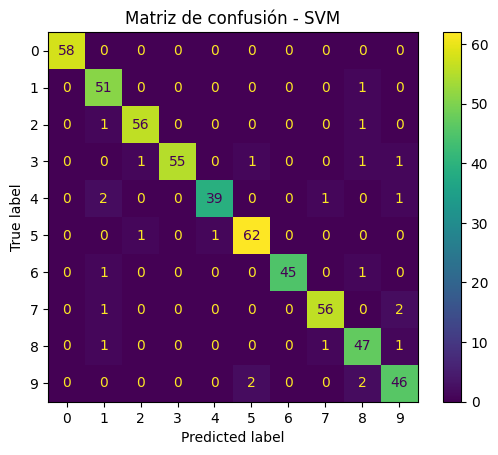

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       0.89      0.98      0.94        52
           2       0.97      0.97      0.97        58
           3       1.00      0.93      0.96        59
           4       0.97      0.91      0.94        43
           5       0.95      0.97      0.96        64
           6       1.00      0.96      0.98        47
           7       0.97      0.95      0.96        59
           8       0.89      0.94      0.91        50
           9       0.90      0.92      0.91        50

    accuracy                           0.95       540
   macro avg       0.95      0.95      0.95       540
weighted avg       0.96      0.95      0.95       540


Modelo evaluado: KNN
Accuracy: 0.9833


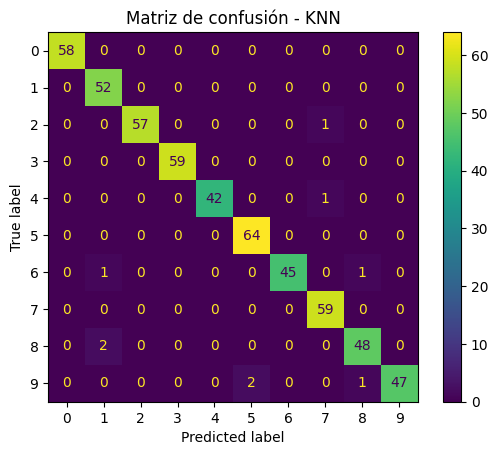

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       0.95      1.00      0.97        52
           2       1.00      0.98      0.99        58
           3       1.00      1.00      1.00        59
           4       1.00      0.98      0.99        43
           5       0.97      1.00      0.98        64
           6       1.00      0.96      0.98        47
           7       0.97      1.00      0.98        59
           8       0.96      0.96      0.96        50
           9       1.00      0.94      0.97        50

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540


Modelo evaluado: Random Forest
Accuracy: 0.9630


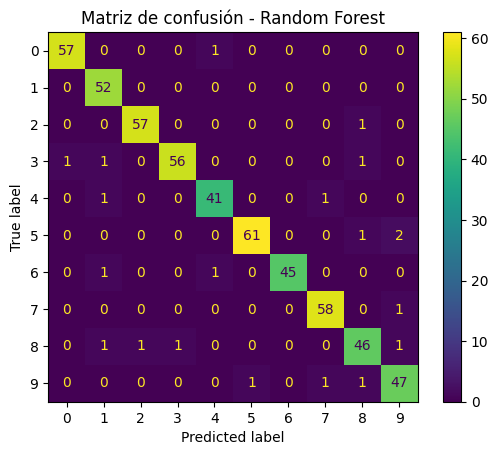

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        58
           1       0.93      1.00      0.96        52
           2       0.98      0.98      0.98        58
           3       0.98      0.95      0.97        59
           4       0.95      0.95      0.95        43
           5       0.98      0.95      0.97        64
           6       1.00      0.96      0.98        47
           7       0.97      0.98      0.97        59
           8       0.92      0.92      0.92        50
           9       0.92      0.94      0.93        50

    accuracy                           0.96       540
   macro avg       0.96      0.96      0.96       540
weighted avg       0.96      0.96      0.96       540


Modelo evaluado: Gradient Boosting
Accuracy: 0.9500


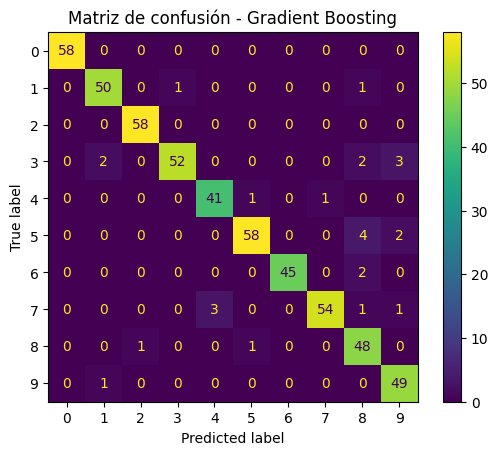

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       0.94      0.96      0.95        52
           2       0.98      1.00      0.99        58
           3       0.98      0.88      0.93        59
           4       0.93      0.95      0.94        43
           5       0.97      0.91      0.94        64
           6       1.00      0.96      0.98        47
           7       0.98      0.92      0.95        59
           8       0.83      0.96      0.89        50
           9       0.89      0.98      0.93        50

    accuracy                           0.95       540
   macro avg       0.95      0.95      0.95       540
weighted avg       0.95      0.95      0.95       540


RESULTADOS FINALES
SVM: 0.9537
KNN: 0.9833
Random Forest: 0.9630
Gradient Boosting: 0.9500

Mejor modelo: KNN
Modelo final entrenado con todo el dataset.


In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


def cargar_datos():
    datos = load_digits()
    X = datos.data
    y = datos.target
    return X, y


def dividir_datos(X, y):
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
        X, y, test_size=0.3, random_state=5
    )

    X_entrenamiento = X_entrenamiento[:1000]
    y_entrenamiento = y_entrenamiento[:1000]
    X_prueba = X_prueba[:1000]
    y_prueba = y_prueba[:1000]

    return X_entrenamiento, X_prueba, y_entrenamiento, y_prueba


def crear_modelos():
    return [
        ("SVM", LinearSVC(max_iter=5000)),
        ("KNN", KNeighborsClassifier(n_neighbors=5)),
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=5)),
        ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, random_state=5))
    ]


def evaluar_modelo(nombre, modelo, X_entrenamiento, X_prueba, y_entrenamiento, y_prueba):
    print("\n" + "=" * 35)
    print("Modelo evaluado:", nombre)
    print("=" * 35)

    modelo.fit(X_entrenamiento, y_entrenamiento)
    predicciones = modelo.predict(X_prueba)

    exactitud = accuracy_score(y_prueba, predicciones)
    print(f"Accuracy: {exactitud:.4f}")

    matriz = confusion_matrix(y_prueba, predicciones)
    visualizador = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=modelo.classes_
    )
    visualizador.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    reporte = classification_report(y_prueba, predicciones)
    print("Reporte de clasificación:")
    print(reporte)

    return exactitud


def mostrar_resumen(resultados):
    print("\n" + "=" * 35)
    print("RESULTADOS FINALES")
    print("=" * 35)

    for nombre, valor in resultados.items():
        print(f"{nombre}: {valor:.4f}")

    mejor_nombre = max(resultados, key=resultados.get)
    print(f"\nMejor modelo: {mejor_nombre}")
    return mejor_nombre


def entrenar_modelo_final(modelos, mejor_nombre, X, y):
    for nombre, modelo in modelos:
        if nombre == mejor_nombre:
            modelo.fit(X, y)
            print("Modelo final entrenado con todo el dataset.")
            return modelo


def main():
    X, y = cargar_datos()
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = dividir_datos(X, y)
    modelos = crear_modelos()

    resultados = {}

    for nombre, modelo in modelos:
        accuracy = evaluar_modelo(
            nombre,
            modelo,
            X_entrenamiento,
            X_prueba,
            y_entrenamiento,
            y_prueba
        )
        resultados[nombre] = accuracy

    mejor_nombre = mostrar_resumen(resultados)
    modelo_final = entrenar_modelo_final(modelos, mejor_nombre, X, y)


if __name__ == "__main__":
    main()